In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.0 MB/s eta 0:00:00


90-5-5


👉 Vui lòng chọn các file sau:
- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv
- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv


Saving BAC.csv to BAC (3).csv
Saving FED_RATE.csv to FED_RATE (3).csv
Saving JPM.csv to JPM (3).csv
Saving SPX500.csv to SPX500 (3).csv
Saving VIX.csv to VIX (3).csv
Saving WFC.csv to WFC (3).csv

🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...

🚀 BẮT ĐẦU PHÂN TÍCH GARCH...

 ĐANG XỬ LÝ: JPM
   + Data Split: Total=1976 | Train=1778 | Val=98 | Test=100
   + Tham số mô hình (Train):
     Omega: 0.1967, Alpha: 0.1195, Beta: 0.8108
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.5036, MAE=1.1306
   + Kết quả Test:       RMSE=0.8318, MAE=0.7056


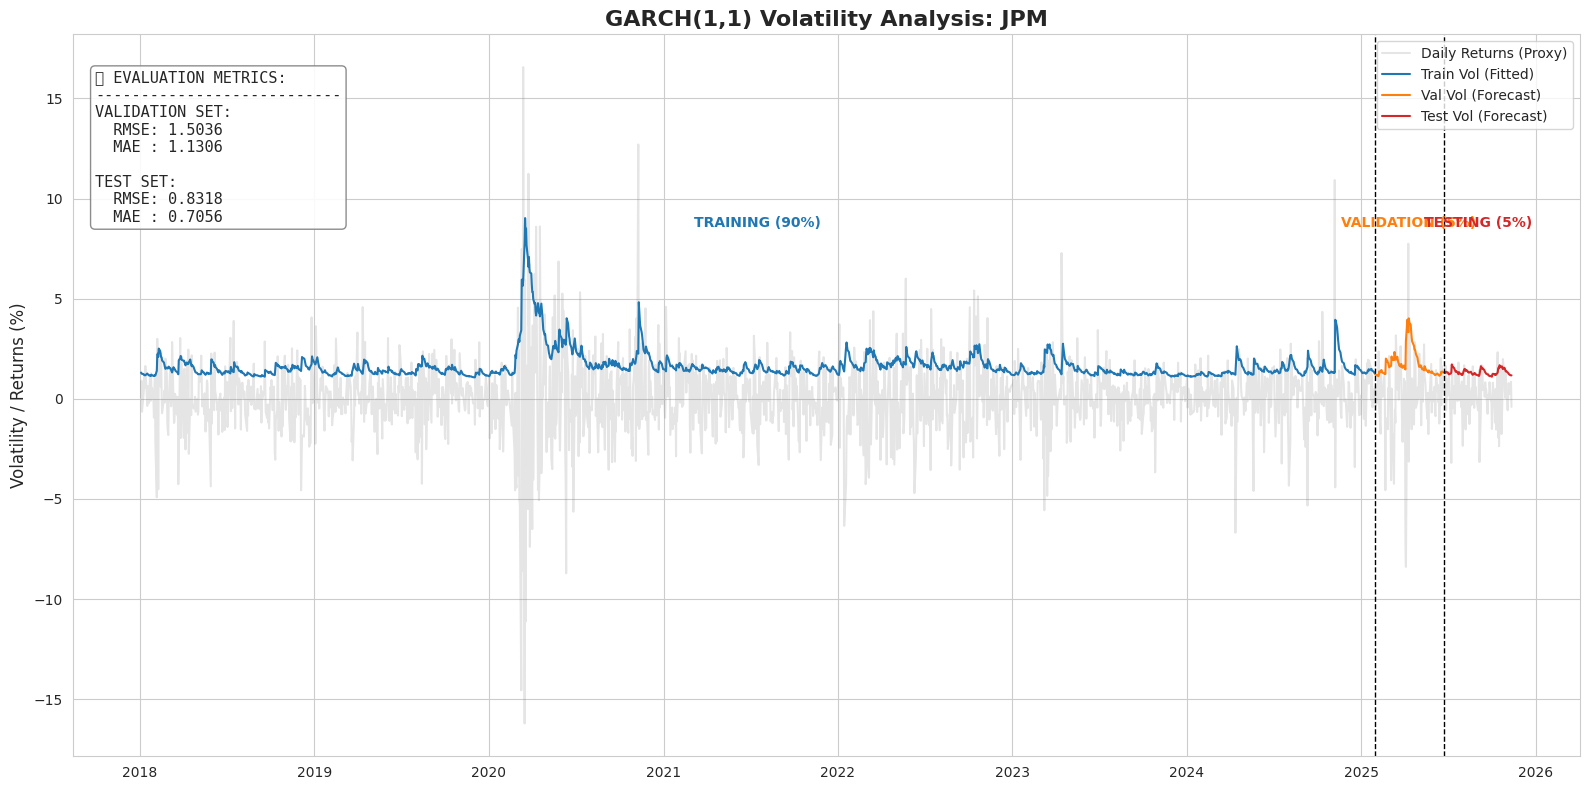


 ĐANG XỬ LÝ: BAC
   + Data Split: Total=1976 | Train=1778 | Val=98 | Test=100
   + Tham số mô hình (Train):
     Omega: 0.3076, Alpha: 0.1409, Beta: 0.7734
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.7518, MAE=1.2576
   + Kết quả Test:       RMSE=1.0249, MAE=0.9178


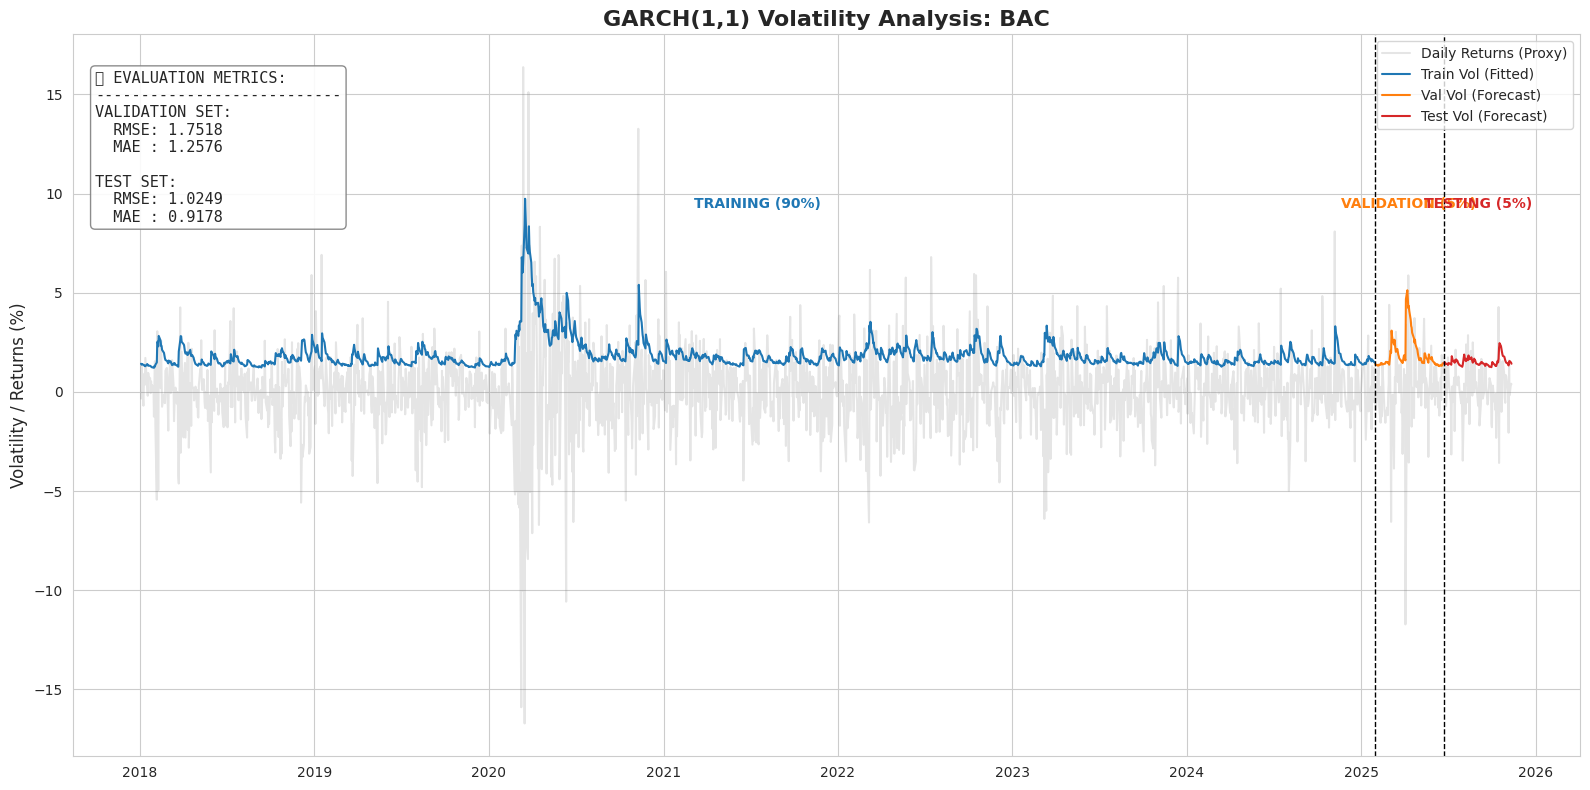


 ĐANG XỬ LÝ: WFC
   + Data Split: Total=1973 | Train=1775 | Val=98 | Test=100
   + Tham số mô hình (Train):
     Omega: 0.0921, Alpha: 0.0614, Beta: 0.9170
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.7154, MAE=1.3062
   + Kết quả Test:       RMSE=1.3240, MAE=1.0810


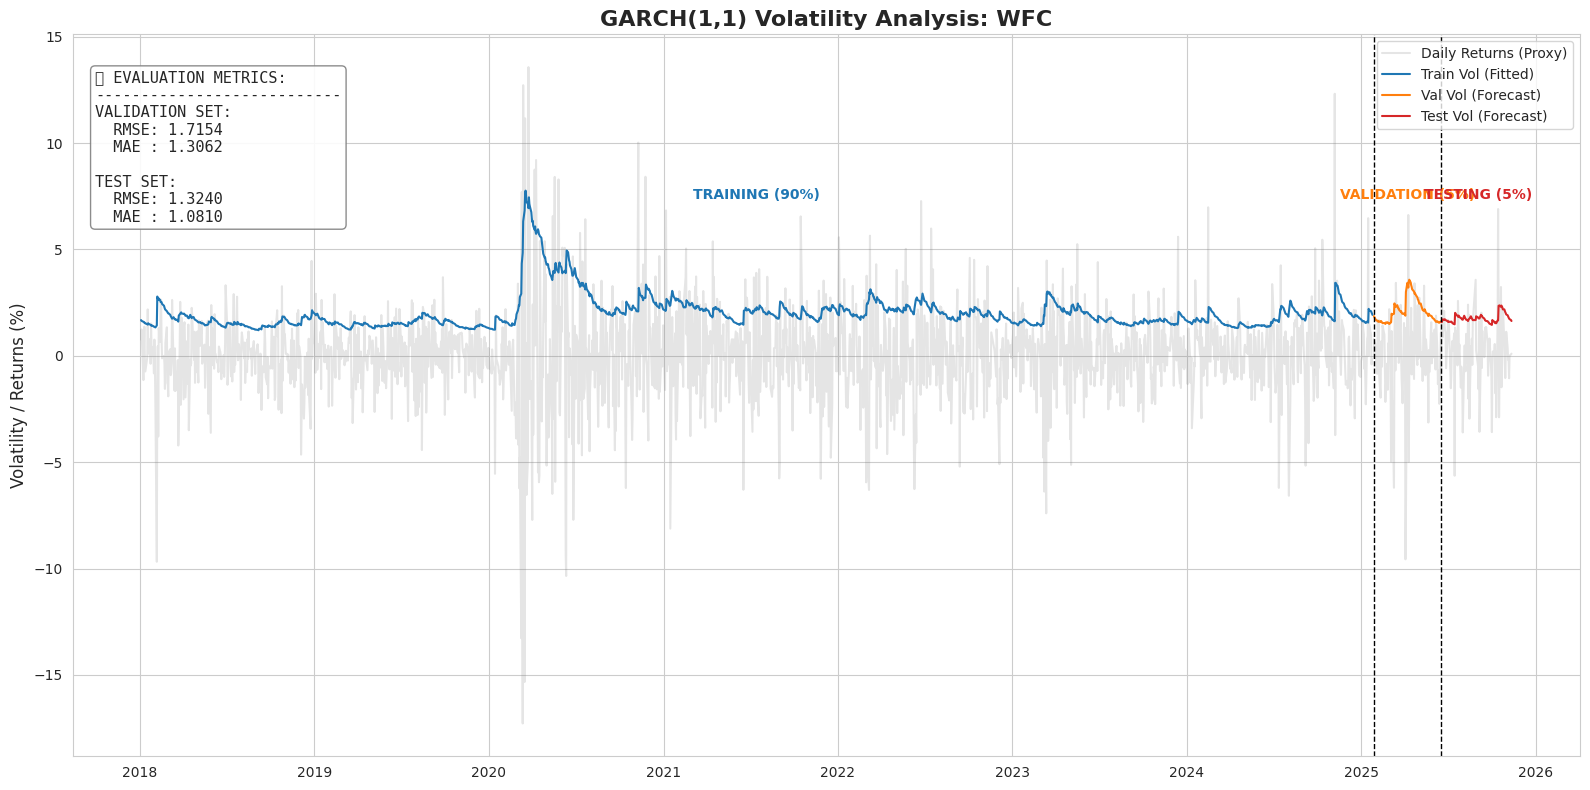

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
from google.colab import files
from arch import arch_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Cấu hình giao diện
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ============================================================
# 1. HÀM XỬ LÝ DỮ LIỆU
# ============================================================
def process_file_macro(filename, content):
    """Đọc và chuẩn hóa ngày tháng"""
    try:
        df = pd.read_csv(io.BytesIO(content))
        date_cols = [c for c in df.columns if 'date' in c.lower()]
        if not date_cols:
            return None
        date_col = date_cols[0]
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=False, errors='coerce').dt.normalize()
        df = df.set_index(date_col).sort_index()
        df = df[df.index.notnull()]
        df = df[~df.index.duplicated(keep='first')]
        return df
    except Exception as e:
        print(f"❌ Lỗi đọc file {filename}: {e}")
        return None

# ============================================================
# CẬP NHẬT HÀM TÍNH TOÁN: DÙNG MAE THAY VÌ MAPE
# ============================================================
def calculate_metrics(true_returns, pred_volatility):
    """
    Tính RMSE và MAE (Thay cho MAPE bị lỗi).
    Proxy cho biến động thực tế (True Volatility) là |Returns|
    """
    true_vol = np.abs(true_returns)

    # 1. RMSE (Root Mean Squared Error) - Nhạy cảm với sai số lớn
    rmse = np.sqrt(mean_squared_error(true_vol, pred_volatility))

    # 2. MAE (Mean Absolute Error) - Sai số tuyệt đối trung bình (Dễ hiểu hơn MAPE)
    mae = mean_absolute_error(true_vol, pred_volatility)

    return rmse, mae
# ============================================================
# 3. HÀM CHẠY GARCH (SPLIT 90-5-5)
# ============================================================
def prepare_returns(df):
    col_price = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    returns = 100 * np.log(df[col_price] / df[col_price].shift(1))
    return returns.dropna()

def fit_and_forecast_garch(returns_series, split_ratios=(0.9, 0.05, 0.05)):
    n = len(returns_series)
    train_size = int(n * split_ratios[0])
    val_size = int(n * split_ratios[1])

    # Chia dữ liệu
    train_data = returns_series.iloc[:train_size]
    val_data = returns_series.iloc[train_size : train_size + val_size]
    test_data = returns_series.iloc[train_size + val_size:]

    print(f"   + Data Split: Total={n} | Train={len(train_data)} | Val={len(val_data)} | Test={len(test_data)}")

    # 1. Huấn luyện trên tập TRAIN
    model = arch_model(train_data, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
    res = model.fit(disp='off')
    print("   + Tham số mô hình (Train):")
    print(f"     Omega: {res.params['omega']:.4f}, Alpha: {res.params['alpha[1]']:.4f}, Beta: {res.params['beta[1]']:.4f}")

    # 2. Dự báo (Rolling Forecast)
    def rolling_forecast(target_data, start_idx):
        forecasts = []
        for i in range(len(target_data)):
            current_history = returns_series.iloc[:start_idx + i]
            mod_temp = arch_model(current_history, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
            res_temp = mod_temp.fix(res.params)
            fcast = res_temp.forecast(horizon=1)
            forecasts.append(np.sqrt(fcast.variance.values[-1, 0]))
        return pd.Series(forecasts, index=target_data.index)

    print("   + Đang dự báo tập Validation...")
    vol_val = rolling_forecast(val_data, train_size)

    print("   + Đang dự báo tập Test...")
    vol_test = rolling_forecast(test_data, train_size + val_size)

    vol_train = res.conditional_volatility

    return train_data, val_data, test_data, vol_train, vol_val, vol_test

# ============================================================
# CẬP NHẬT HÀM VẼ: HIỂN THỊ MAE
# ============================================================
def plot_garch_results(ticker, train_data, val_data, test_data, vol_train, vol_val, vol_test, metrics):
    plt.figure(figsize=(16, 8))

    # Vẽ Returns (Nền mờ)
    plt.plot(train_data.index, train_data, color='gray', alpha=0.2, label='Daily Returns (Proxy)')
    plt.plot(val_data.index, val_data, color='gray', alpha=0.2)
    plt.plot(test_data.index, test_data, color='gray', alpha=0.2)

    # Vẽ Volatility (Đậm)
    plt.plot(vol_train.index, vol_train, color='#1f77b4', linewidth=1.5, label='Train Vol (Fitted)')
    plt.plot(vol_val.index, vol_val, color='#ff7f0e', linewidth=1.5, label='Val Vol (Forecast)')
    plt.plot(vol_test.index, vol_test, color='#d62728', linewidth=1.5, label='Test Vol (Forecast)')

    # Đường phân cách
    plt.axvline(x=val_data.index[0], color='black', linestyle='--', linewidth=1)
    plt.axvline(x=test_data.index[0], color='black', linestyle='--', linewidth=1)

    # Label khu vực
    y_max = max(vol_train.max(), vol_val.max(), vol_test.max()) * 0.95
    plt.text(train_data.index[int(len(train_data)/2)], y_max, 'TRAINING (90%)', ha='center', fontweight='bold', color='#1f77b4')
    plt.text(val_data.index[int(len(val_data)/2)], y_max, 'VALIDATION (5%)', ha='center', fontweight='bold', color='#ff7f0e')
    plt.text(test_data.index[int(len(test_data)/2)], y_max, 'TESTING (5%)', ha='center', fontweight='bold', color='#d62728')

    # --- HIỂN THỊ METRICS (RMSE & MAE) ---
    rmse_val, mae_val = metrics['val']
    rmse_test, mae_test = metrics['test']

    stats_text = (
        f"📊 EVALUATION METRICS:\n"
        f"---------------------------\n"
        f"VALIDATION SET:\n"
        f"  RMSE: {rmse_val:.4f}\n"
        f"  MAE : {mae_val:.4f}\n\n"
        f"TEST SET:\n"
        f"  RMSE: {rmse_test:.4f}\n"
        f"  MAE : {mae_test:.4f}"
    )

    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    plt.gca().text(0.015, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=props, fontfamily='monospace')

    plt.title(f'GARCH(1,1) Volatility Analysis: {ticker}', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility / Returns (%)', fontsize=12)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. MAIN EXECUTION (UPLOAD VÀ CHẠY) - ĐÃ SỬA NHÃN IN RA
# ============================================================
print("\n👉 Vui lòng chọn các file sau:")
print("- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv")
print("- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv")

uploaded = files.upload()
data_dict = {}

print("\n🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...")
for name, content in uploaded.items():
    name_upper = name.upper()
    df = process_file_macro(name, content)
    if df is not None:
        if 'JPM' in name_upper: data_dict['JPM'] = df
        elif 'BAC' in name_upper: data_dict['BAC'] = df
        elif 'WFC' in name_upper: data_dict['WFC'] = df
        elif 'VIX' in name_upper: data_dict['VIX'] = df
        elif 'FED' in name_upper: data_dict['FED'] = df

target_tickers = ['JPM', 'BAC', 'WFC']

print("\n🚀 BẮT ĐẦU PHÂN TÍCH GARCH...")
for ticker in target_tickers:
    if ticker in data_dict:
        print(f"\n{'='*60}")
        print(f" ĐANG XỬ LÝ: {ticker}")
        print(f"{'='*60}")

        # 1. Chuẩn bị dữ liệu
        returns = prepare_returns(data_dict[ticker])

        # 2. Chạy mô hình
        tr_d, val_d, te_d, tr_v, val_v, te_v = fit_and_forecast_garch(returns)

        # 3. Tính toán độ chính xác (RMSE, MAE)
        # SỬA Ở ĐÂY: Đổi tên biến nhận về thành mae_val, mae_test
        rmse_val, mae_val = calculate_metrics(val_d, val_v)
        rmse_test, mae_test = calculate_metrics(te_d, te_v)

        # Đóng gói kết quả để vẽ
        metrics_pack = {
            'val': (rmse_val, mae_val),
            'test': (rmse_test, mae_test)
        }

        # SỬA Ở ĐÂY: Sửa nhãn in ra từ MAPE thành MAE
        print(f"   + Kết quả Validation: RMSE={rmse_val:.4f}, MAE={mae_val:.4f}")
        print(f"   + Kết quả Test:       RMSE={rmse_test:.4f}, MAE={mae_test:.4f}")

        # 4. Vẽ biểu đồ
        plot_garch_results(ticker, tr_d, val_d, te_d, tr_v, val_v, te_v, metrics_pack)

    else:
        print(f"⚠️ Không tìm thấy dữ liệu cho {ticker}. Vui lòng kiểm tra tên file.")

80-10-10


👉 Vui lòng chọn các file sau:
- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv
- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv


Saving BAC.csv to BAC (6).csv
Saving FED_RATE.csv to FED_RATE (6).csv
Saving JPM.csv to JPM (6).csv
Saving SPX500.csv to SPX500 (6).csv
Saving VIX.csv to VIX (6).csv
Saving WFC.csv to WFC (6).csv

🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...

🚀 BẮT ĐẦU PHÂN TÍCH GARCH...

 ĐANG XỬ LÝ: JPM
   + Data Split: Total=1976 | Train=1580 | Val=197 | Test=199
   + Tham số mô hình (Train):
     Omega: 0.1022, Alpha: 0.1042, Beta: 0.8617
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.3497, MAE=0.9833
   + Kết quả Test:       RMSE=1.2252, MAE=0.9195


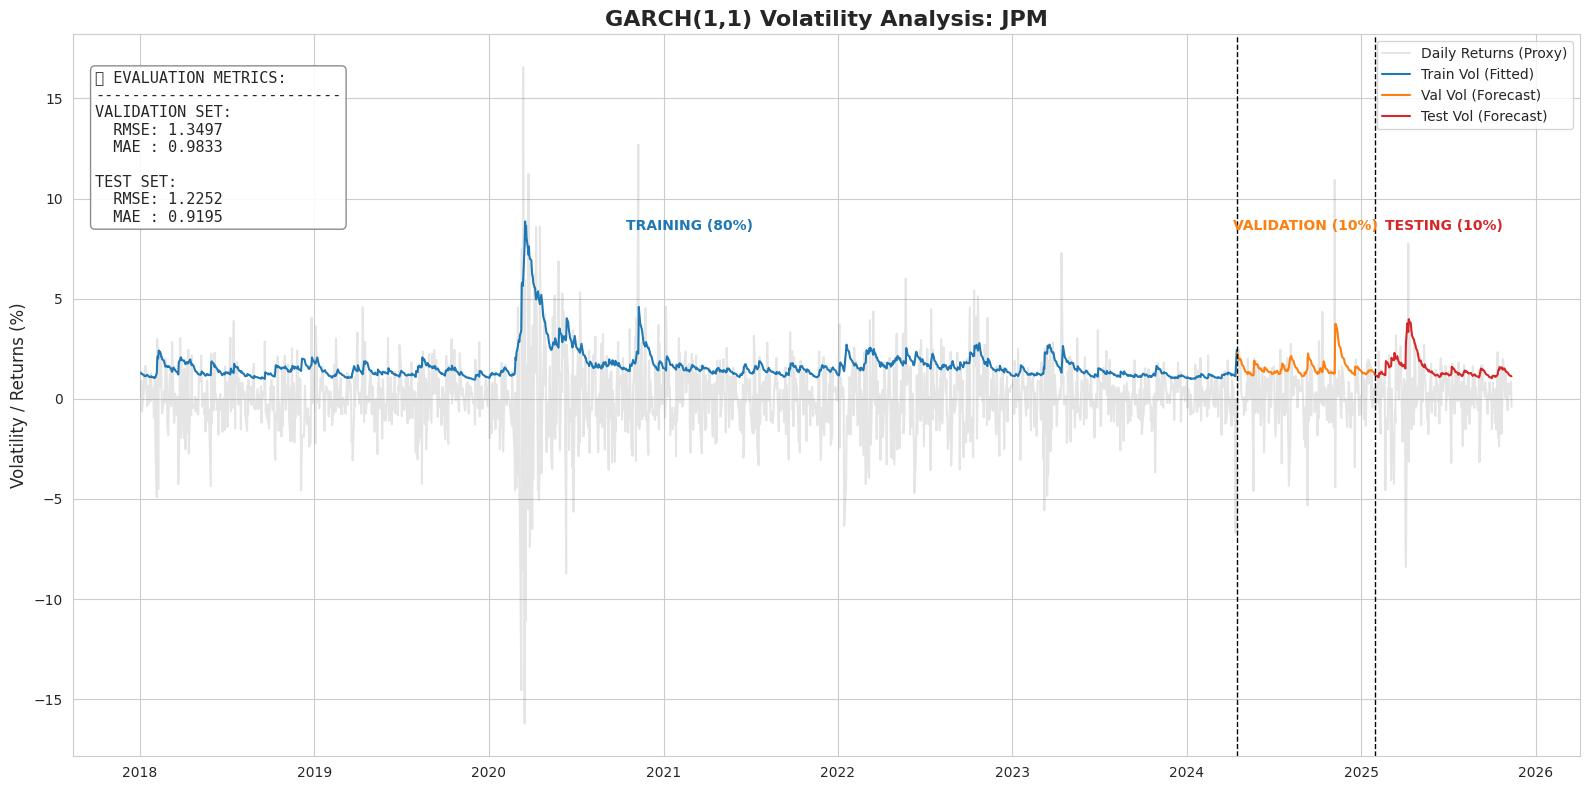


 ĐANG XỬ LÝ: BAC
   + Data Split: Total=1976 | Train=1580 | Val=197 | Test=199
   + Tham số mô hình (Train):
     Omega: 0.2594, Alpha: 0.1462, Beta: 0.7868
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.2309, MAE=0.9602
   + Kết quả Test:       RMSE=1.4411, MAE=1.0917


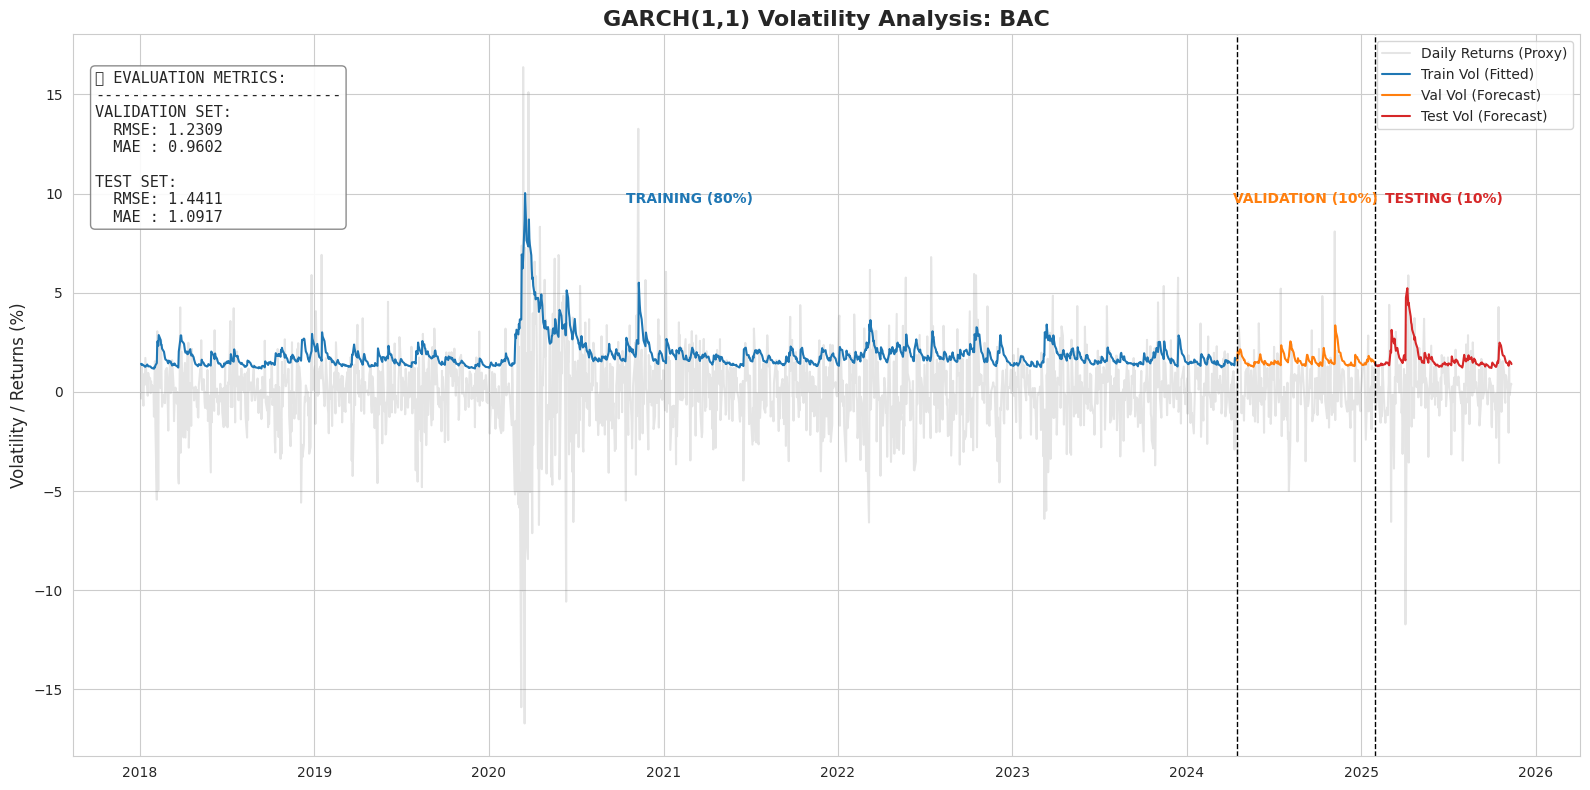


 ĐANG XỬ LÝ: WFC
   + Data Split: Total=1973 | Train=1578 | Val=197 | Test=198
   + Tham số mô hình (Train):
     Omega: 0.1794, Alpha: 0.1154, Beta: 0.8442
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.6293, MAE=1.1774
   + Kết quả Test:       RMSE=1.5169, MAE=1.1653


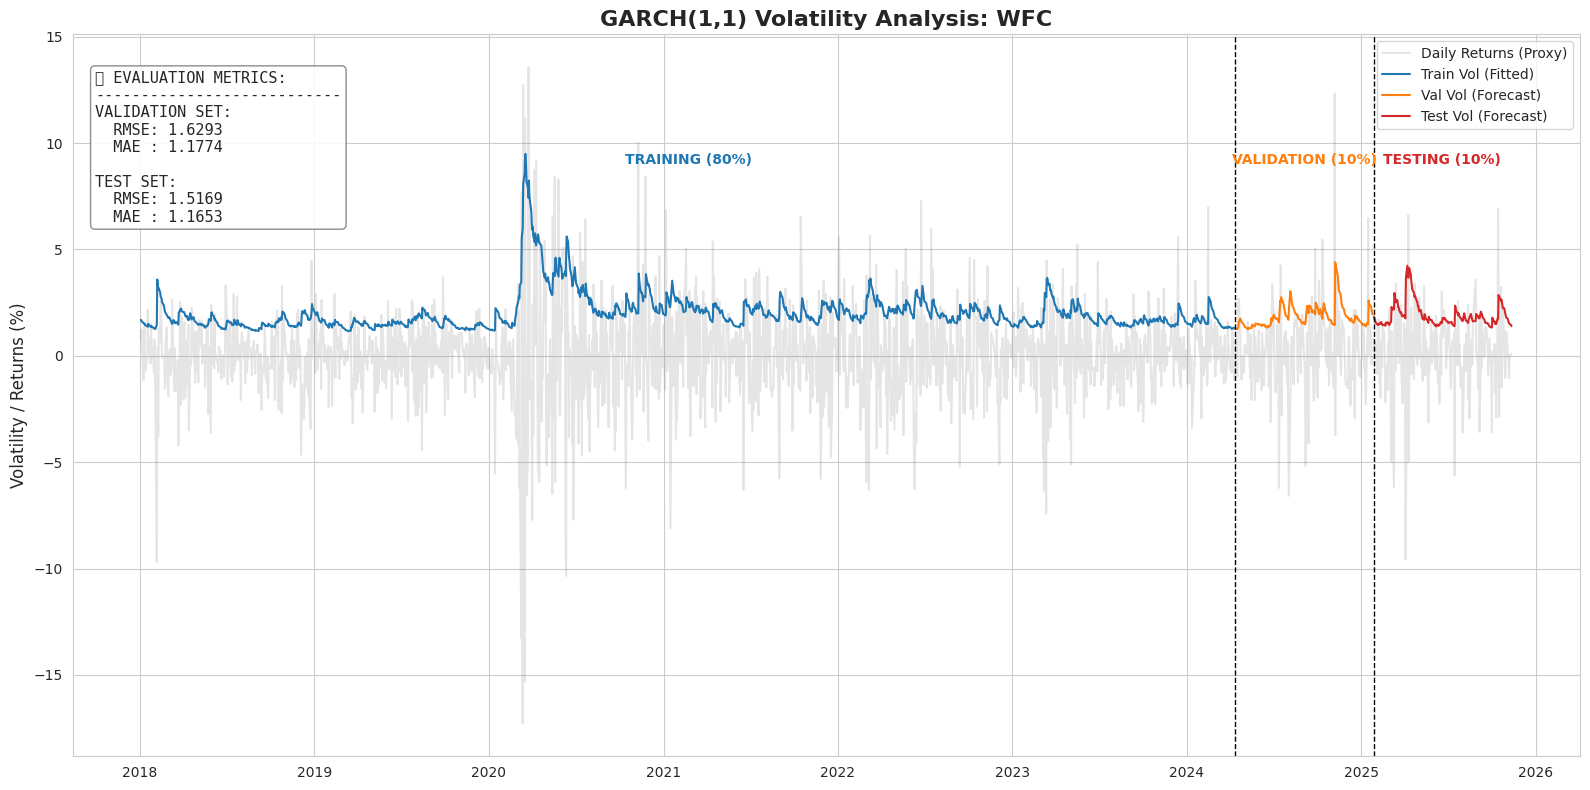

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
from google.colab import files
from arch import arch_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Cấu hình giao diện
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ============================================================
# 1. HÀM XỬ LÝ DỮ LIỆU
# ============================================================
def process_file_macro(filename, content):
    """Đọc và chuẩn hóa ngày tháng"""
    try:
        df = pd.read_csv(io.BytesIO(content))
        date_cols = [c for c in df.columns if 'date' in c.lower()]
        if not date_cols:
            return None
        date_col = date_cols[0]
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=False, errors='coerce').dt.normalize()
        df = df.set_index(date_col).sort_index()
        df = df[df.index.notnull()]
        df = df[~df.index.duplicated(keep='first')]
        return df
    except Exception as e:
        print(f"❌ Lỗi đọc file {filename}: {e}")
        return None

# ============================================================
# CẬP NHẬT HÀM TÍNH TOÁN: DÙNG MAE THAY VÌ MAPE
# ============================================================
def calculate_metrics(true_returns, pred_volatility):
    """
    Tính RMSE và MAE (Thay cho MAPE bị lỗi).
    Proxy cho biến động thực tế (True Volatility) là |Returns|
    """
    true_vol = np.abs(true_returns)

    # 1. RMSE (Root Mean Squared Error) - Nhạy cảm với sai số lớn
    rmse = np.sqrt(mean_squared_error(true_vol, pred_volatility))

    # 2. MAE (Mean Absolute Error) - Sai số tuyệt đối trung bình (Dễ hiểu hơn MAPE)
    mae = mean_absolute_error(true_vol, pred_volatility)

    return rmse, mae
# ============================================================
# 3. HÀM CHẠY GARCH (SPLIT 80-10-10)
# ============================================================
def prepare_returns(df):
    col_price = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    returns = 100 * np.log(df[col_price] / df[col_price].shift(1))
    return returns.dropna()

def fit_and_forecast_garch(returns_series, split_ratios=(0.8, 0.1, 0.1)):
    n = len(returns_series)
    train_size = int(n * split_ratios[0])
    val_size = int(n * split_ratios[1])

    # Chia dữ liệu
    train_data = returns_series.iloc[:train_size]
    val_data = returns_series.iloc[train_size : train_size + val_size]
    test_data = returns_series.iloc[train_size + val_size:]

    print(f"   + Data Split: Total={n} | Train={len(train_data)} | Val={len(val_data)} | Test={len(test_data)}")

    # 1. Huấn luyện trên tập TRAIN
    model = arch_model(train_data, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
    res = model.fit(disp='off')
    print("   + Tham số mô hình (Train):")
    print(f"     Omega: {res.params['omega']:.4f}, Alpha: {res.params['alpha[1]']:.4f}, Beta: {res.params['beta[1]']:.4f}")

    # 2. Dự báo (Rolling Forecast)
    def rolling_forecast(target_data, start_idx):
        forecasts = []
        for i in range(len(target_data)):
            current_history = returns_series.iloc[:start_idx + i]
            mod_temp = arch_model(current_history, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
            res_temp = mod_temp.fix(res.params)
            fcast = res_temp.forecast(horizon=1)
            forecasts.append(np.sqrt(fcast.variance.values[-1, 0]))
        return pd.Series(forecasts, index=target_data.index)

    print("   + Đang dự báo tập Validation...")
    vol_val = rolling_forecast(val_data, train_size)

    print("   + Đang dự báo tập Test...")
    vol_test = rolling_forecast(test_data, train_size + val_size)

    vol_train = res.conditional_volatility

    return train_data, val_data, test_data, vol_train, vol_val, vol_test

# ============================================================
# CẬP NHẬT HÀM VẼ: HIỂN THỊ MAE
# ============================================================
def plot_garch_results(ticker, train_data, val_data, test_data, vol_train, vol_val, vol_test, metrics):
    plt.figure(figsize=(16, 8))

    # Vẽ Returns (Nền mờ)
    plt.plot(train_data.index, train_data, color='gray', alpha=0.2, label='Daily Returns (Proxy)')
    plt.plot(val_data.index, val_data, color='gray', alpha=0.2)
    plt.plot(test_data.index, test_data, color='gray', alpha=0.2)

    # Vẽ Volatility (Đậm)
    plt.plot(vol_train.index, vol_train, color='#1f77b4', linewidth=1.5, label='Train Vol (Fitted)')
    plt.plot(vol_val.index, vol_val, color='#ff7f0e', linewidth=1.5, label='Val Vol (Forecast)')
    plt.plot(vol_test.index, vol_test, color='#d62728', linewidth=1.5, label='Test Vol (Forecast)')

    # Đường phân cách
    plt.axvline(x=val_data.index[0], color='black', linestyle='--', linewidth=1)
    plt.axvline(x=test_data.index[0], color='black', linestyle='--', linewidth=1)

    # Label khu vực
    y_max = max(vol_train.max(), vol_val.max(), vol_test.max()) * 0.95
    plt.text(train_data.index[int(len(train_data)/2)], y_max, 'TRAINING (80%)', ha='center', fontweight='bold', color='#1f77b4')
    plt.text(val_data.index[int(len(val_data)/2)], y_max, 'VALIDATION (10%)', ha='center', fontweight='bold', color='#ff7f0e')
    plt.text(test_data.index[int(len(test_data)/2)], y_max, 'TESTING (10%)', ha='center', fontweight='bold', color='#d62728')

    # --- HIỂN THỊ METRICS (RMSE & MAE) ---
    rmse_val, mae_val = metrics['val']
    rmse_test, mae_test = metrics['test']

    stats_text = (
        f"📊 EVALUATION METRICS:\n"
        f"---------------------------\n"
        f"VALIDATION SET:\n"
        f"  RMSE: {rmse_val:.4f}\n"
        f"  MAE : {mae_val:.4f}\n\n"
        f"TEST SET:\n"
        f"  RMSE: {rmse_test:.4f}\n"
        f"  MAE : {mae_test:.4f}"
    )

    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    plt.gca().text(0.015, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=props, fontfamily='monospace')

    plt.title(f'GARCH(1,1) Volatility Analysis: {ticker}', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility / Returns (%)', fontsize=12)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. MAIN EXECUTION (UPLOAD VÀ CHẠY) - ĐÃ SỬA NHÃN IN RA
# ============================================================
print("\n👉 Vui lòng chọn các file sau:")
print("- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv")
print("- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv")

uploaded = files.upload()
data_dict = {}

print("\n🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...")
for name, content in uploaded.items():
    name_upper = name.upper()
    df = process_file_macro(name, content)
    if df is not None:
        if 'JPM' in name_upper: data_dict['JPM'] = df
        elif 'BAC' in name_upper: data_dict['BAC'] = df
        elif 'WFC' in name_upper: data_dict['WFC'] = df
        elif 'VIX' in name_upper: data_dict['VIX'] = df
        elif 'FED' in name_upper: data_dict['FED'] = df

target_tickers = ['JPM', 'BAC', 'WFC']

print("\n🚀 BẮT ĐẦU PHÂN TÍCH GARCH...")
for ticker in target_tickers:
    if ticker in data_dict:
        print(f"\n{'='*60}")
        print(f" ĐANG XỬ LÝ: {ticker}")
        print(f"{'='*60}")

        # 1. Chuẩn bị dữ liệu
        returns = prepare_returns(data_dict[ticker])

        # 2. Chạy mô hình
        tr_d, val_d, te_d, tr_v, val_v, te_v = fit_and_forecast_garch(returns)

        # 3. Tính toán độ chính xác (RMSE, MAE)
        # SỬA Ở ĐÂY: Đổi tên biến nhận về thành mae_val, mae_test
        rmse_val, mae_val = calculate_metrics(val_d, val_v)
        rmse_test, mae_test = calculate_metrics(te_d, te_v)

        # Đóng gói kết quả để vẽ
        metrics_pack = {
            'val': (rmse_val, mae_val),
            'test': (rmse_test, mae_test)
        }

        # SỬA Ở ĐÂY: Sửa nhãn in ra từ MAPE thành MAE
        print(f"   + Kết quả Validation: RMSE={rmse_val:.4f}, MAE={mae_val:.4f}")
        print(f"   + Kết quả Test:       RMSE={rmse_test:.4f}, MAE={mae_test:.4f}")

        # 4. Vẽ biểu đồ
        plot_garch_results(ticker, tr_d, val_d, te_d, tr_v, val_v, te_v, metrics_pack)

    else:
        print(f"⚠️ Không tìm thấy dữ liệu cho {ticker}. Vui lòng kiểm tra tên file.")

70-15-15


👉 Vui lòng chọn các file sau:
- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv
- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv


Saving BAC.csv to BAC (5).csv
Saving FED_RATE.csv to FED_RATE (5).csv
Saving JPM.csv to JPM (5).csv
Saving SPX500.csv to SPX500 (5).csv
Saving VIX.csv to VIX (5).csv
Saving WFC.csv to WFC (5).csv

🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...

🚀 BẮT ĐẦU PHÂN TÍCH GARCH...

 ĐANG XỬ LÝ: JPM
   + Data Split: Total=1976 | Train=1383 | Val=296 | Test=297
   + Tham số mô hình (Train):
     Omega: 0.1445, Alpha: 0.1170, Beta: 0.8376
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=0.9363, MAE=0.7514
   + Kết quả Test:       RMSE=1.3621, MAE=0.9883


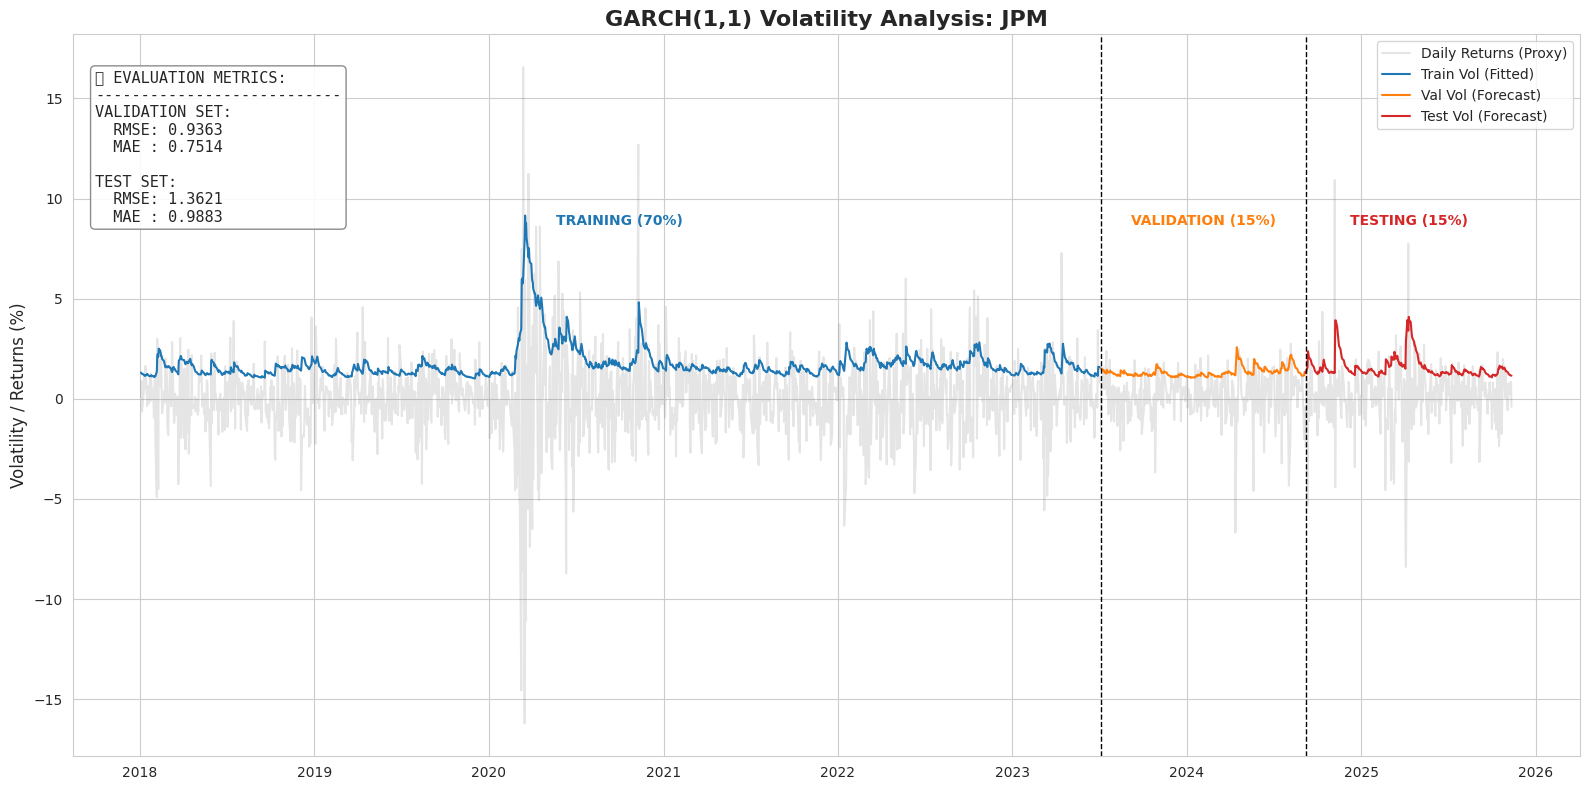


 ĐANG XỬ LÝ: BAC
   + Data Split: Total=1976 | Train=1383 | Val=296 | Test=297
   + Tham số mô hình (Train):
     Omega: 0.2689, Alpha: 0.1590, Beta: 0.7772
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.1564, MAE=0.9578
   + Kết quả Test:       RMSE=1.4146, MAE=1.0755


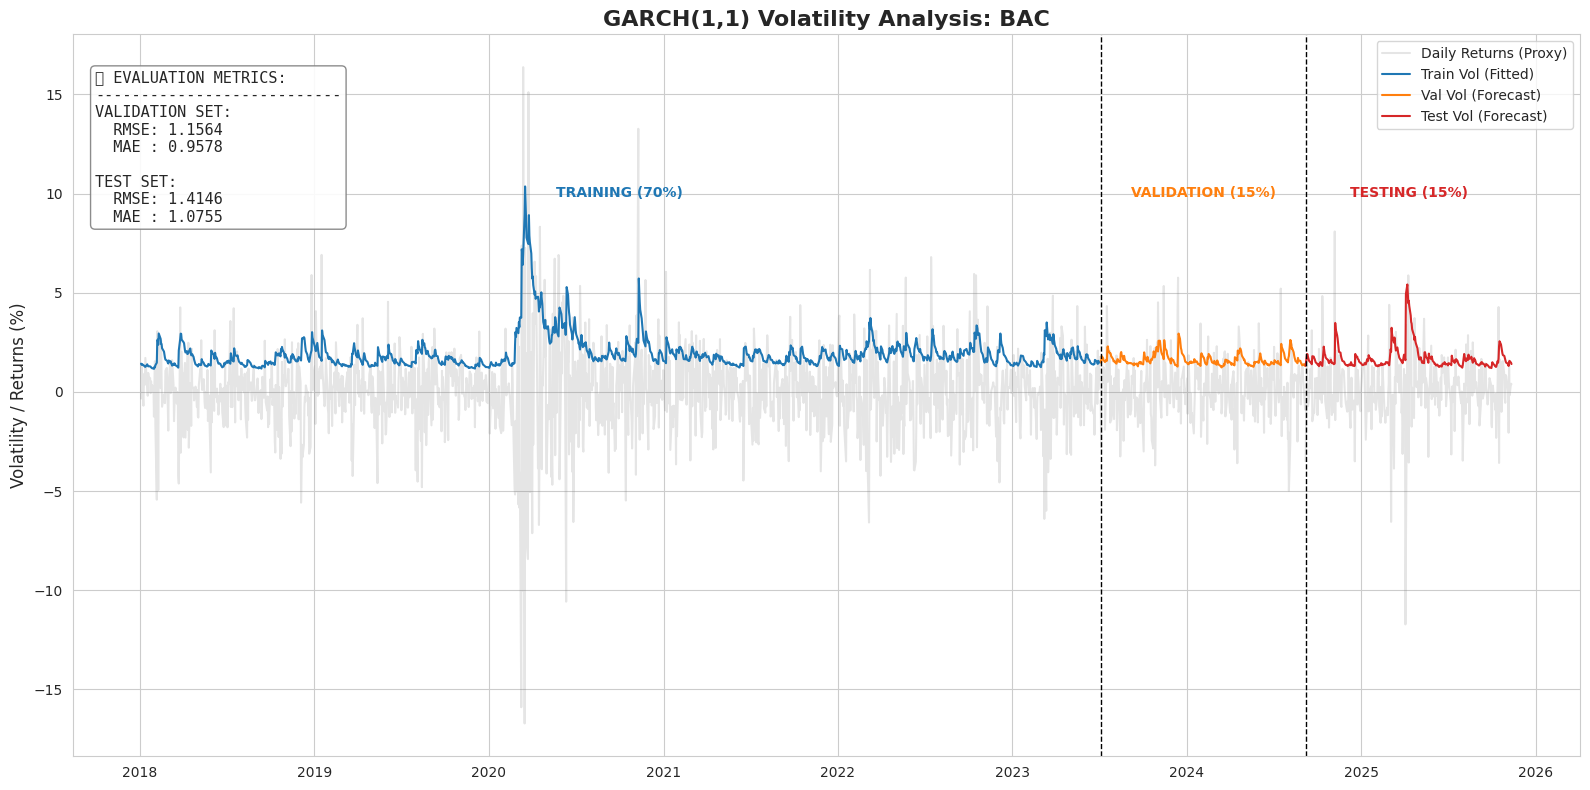


 ĐANG XỬ LÝ: WFC
   + Data Split: Total=1973 | Train=1381 | Val=295 | Test=297
   + Tham số mô hình (Train):
     Omega: 0.2038, Alpha: 0.1297, Beta: 0.8299
   + Đang dự báo tập Validation...
   + Đang dự báo tập Test...
   + Kết quả Validation: RMSE=1.1901, MAE=0.9572
   + Kết quả Test:       RMSE=1.6778, MAE=1.2533


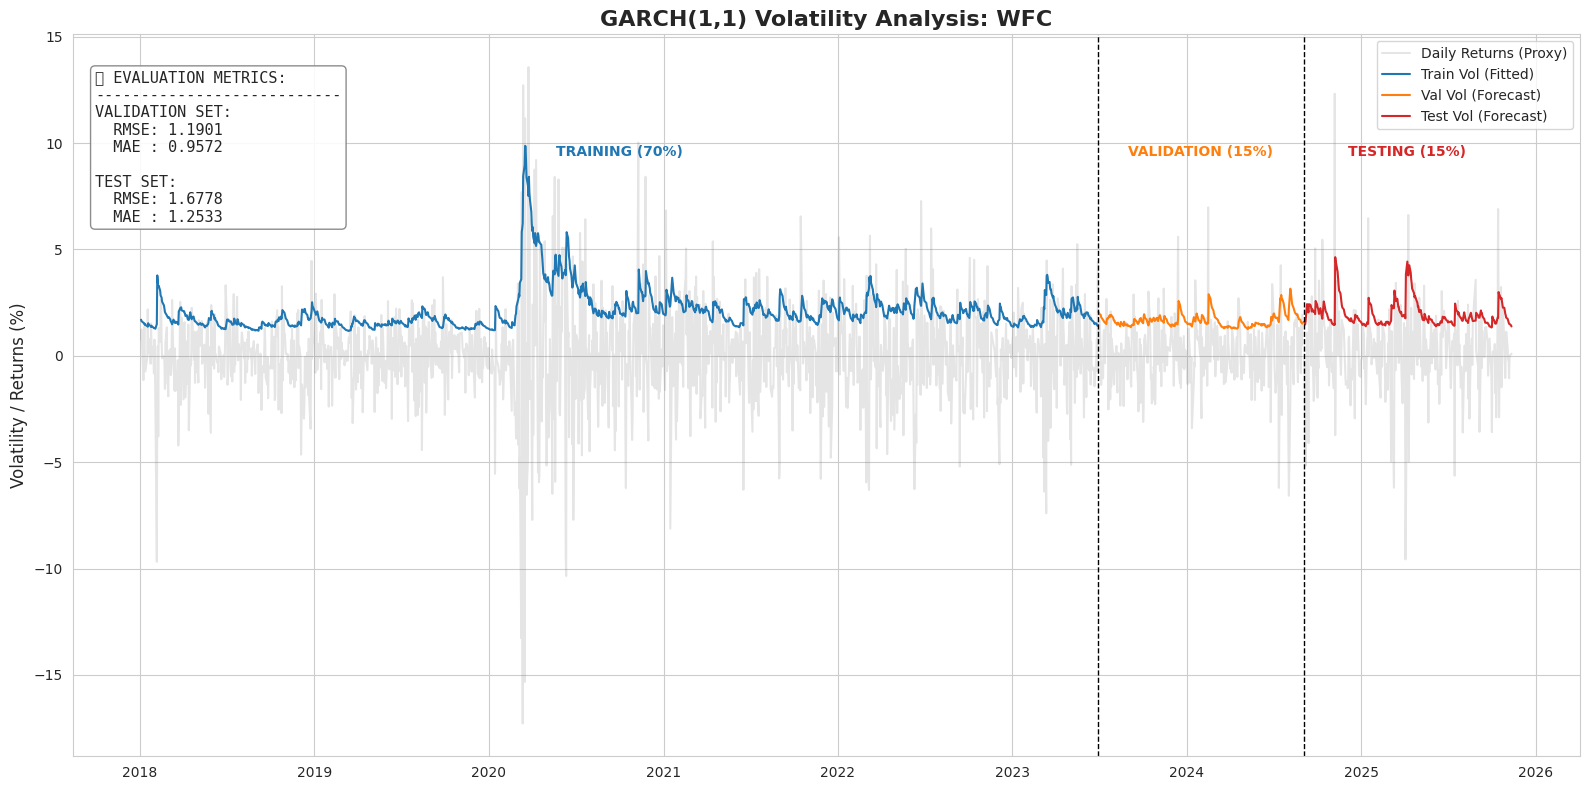

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
from google.colab import files
from arch import arch_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Cấu hình giao diện
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ============================================================
# 1. HÀM XỬ LÝ DỮ LIỆU
# ============================================================
def process_file_macro(filename, content):
    """Đọc và chuẩn hóa ngày tháng"""
    try:
        df = pd.read_csv(io.BytesIO(content))
        date_cols = [c for c in df.columns if 'date' in c.lower()]
        if not date_cols:
            return None
        date_col = date_cols[0]
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=False, errors='coerce').dt.normalize()
        df = df.set_index(date_col).sort_index()
        df = df[df.index.notnull()]
        df = df[~df.index.duplicated(keep='first')]
        return df
    except Exception as e:
        print(f"❌ Lỗi đọc file {filename}: {e}")
        return None

# ============================================================
# CẬP NHẬT HÀM TÍNH TOÁN: DÙNG MAE THAY VÌ MAPE
# ============================================================
def calculate_metrics(true_returns, pred_volatility):
    """
    Tính RMSE và MAE (Thay cho MAPE bị lỗi).
    Proxy cho biến động thực tế (True Volatility) là |Returns|
    """
    true_vol = np.abs(true_returns)

    # 1. RMSE (Root Mean Squared Error) - Nhạy cảm với sai số lớn
    rmse = np.sqrt(mean_squared_error(true_vol, pred_volatility))

    # 2. MAE (Mean Absolute Error) - Sai số tuyệt đối trung bình (Dễ hiểu hơn MAPE)
    mae = mean_absolute_error(true_vol, pred_volatility)

    return rmse, mae
# ============================================================
# 3. HÀM CHẠY GARCH (SPLIT 70-15-15)
# ============================================================
def prepare_returns(df):
    col_price = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    returns = 100 * np.log(df[col_price] / df[col_price].shift(1))
    return returns.dropna()

def fit_and_forecast_garch(returns_series, split_ratios=(0.7, 0.15, 0.15)):
    n = len(returns_series)
    train_size = int(n * split_ratios[0])
    val_size = int(n * split_ratios[1])

    # Chia dữ liệu
    train_data = returns_series.iloc[:train_size]
    val_data = returns_series.iloc[train_size : train_size + val_size]
    test_data = returns_series.iloc[train_size + val_size:]

    print(f"   + Data Split: Total={n} | Train={len(train_data)} | Val={len(val_data)} | Test={len(test_data)}")

    # 1. Huấn luyện trên tập TRAIN
    model = arch_model(train_data, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
    res = model.fit(disp='off')
    print("   + Tham số mô hình (Train):")
    print(f"     Omega: {res.params['omega']:.4f}, Alpha: {res.params['alpha[1]']:.4f}, Beta: {res.params['beta[1]']:.4f}")

    # 2. Dự báo (Rolling Forecast)
    def rolling_forecast(target_data, start_idx):
        forecasts = []
        for i in range(len(target_data)):
            current_history = returns_series.iloc[:start_idx + i]
            mod_temp = arch_model(current_history, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
            res_temp = mod_temp.fix(res.params)
            fcast = res_temp.forecast(horizon=1)
            forecasts.append(np.sqrt(fcast.variance.values[-1, 0]))
        return pd.Series(forecasts, index=target_data.index)

    print("   + Đang dự báo tập Validation...")
    vol_val = rolling_forecast(val_data, train_size)

    print("   + Đang dự báo tập Test...")
    vol_test = rolling_forecast(test_data, train_size + val_size)

    vol_train = res.conditional_volatility

    return train_data, val_data, test_data, vol_train, vol_val, vol_test

# ============================================================
# CẬP NHẬT HÀM VẼ: HIỂN THỊ MAE
# ============================================================
def plot_garch_results(ticker, train_data, val_data, test_data, vol_train, vol_val, vol_test, metrics):
    plt.figure(figsize=(16, 8))

    # Vẽ Returns (Nền mờ)
    plt.plot(train_data.index, train_data, color='gray', alpha=0.2, label='Daily Returns (Proxy)')
    plt.plot(val_data.index, val_data, color='gray', alpha=0.2)
    plt.plot(test_data.index, test_data, color='gray', alpha=0.2)

    # Vẽ Volatility (Đậm)
    plt.plot(vol_train.index, vol_train, color='#1f77b4', linewidth=1.5, label='Train Vol (Fitted)')
    plt.plot(vol_val.index, vol_val, color='#ff7f0e', linewidth=1.5, label='Val Vol (Forecast)')
    plt.plot(vol_test.index, vol_test, color='#d62728', linewidth=1.5, label='Test Vol (Forecast)')

    # Đường phân cách
    plt.axvline(x=val_data.index[0], color='black', linestyle='--', linewidth=1)
    plt.axvline(x=test_data.index[0], color='black', linestyle='--', linewidth=1)

    # Label khu vực
    y_max = max(vol_train.max(), vol_val.max(), vol_test.max()) * 0.95
    plt.text(train_data.index[int(len(train_data)/2)], y_max, 'TRAINING (70%)', ha='center', fontweight='bold', color='#1f77b4')
    plt.text(val_data.index[int(len(val_data)/2)], y_max, 'VALIDATION (15%)', ha='center', fontweight='bold', color='#ff7f0e')
    plt.text(test_data.index[int(len(test_data)/2)], y_max, 'TESTING (15%)', ha='center', fontweight='bold', color='#d62728')

    # --- HIỂN THỊ METRICS (RMSE & MAE) ---
    rmse_val, mae_val = metrics['val']
    rmse_test, mae_test = metrics['test']

    stats_text = (
        f"📊 EVALUATION METRICS:\n"
        f"---------------------------\n"
        f"VALIDATION SET:\n"
        f"  RMSE: {rmse_val:.4f}\n"
        f"  MAE : {mae_val:.4f}\n\n"
        f"TEST SET:\n"
        f"  RMSE: {rmse_test:.4f}\n"
        f"  MAE : {mae_test:.4f}"
    )

    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    plt.gca().text(0.015, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=props, fontfamily='monospace')

    plt.title(f'GARCH(1,1) Volatility Analysis: {ticker}', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility / Returns (%)', fontsize=12)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. MAIN EXECUTION (UPLOAD VÀ CHẠY) - ĐÃ SỬA NHÃN IN RA
# ============================================================
print("\n👉 Vui lòng chọn các file sau:")
print("- Cổ phiếu: JPM.csv, BAC.csv, WFC.csv")
print("- Vĩ mô (Tùy chọn): VIX.csv, FED_RATE.csv")

uploaded = files.upload()
data_dict = {}

print("\n🔍 ĐANG ĐỒNG BỘ DỮ LIỆU...")
for name, content in uploaded.items():
    name_upper = name.upper()
    df = process_file_macro(name, content)
    if df is not None:
        if 'JPM' in name_upper: data_dict['JPM'] = df
        elif 'BAC' in name_upper: data_dict['BAC'] = df
        elif 'WFC' in name_upper: data_dict['WFC'] = df
        elif 'VIX' in name_upper: data_dict['VIX'] = df
        elif 'FED' in name_upper: data_dict['FED'] = df

target_tickers = ['JPM', 'BAC', 'WFC']

print("\n🚀 BẮT ĐẦU PHÂN TÍCH GARCH...")
for ticker in target_tickers:
    if ticker in data_dict:
        print(f"\n{'='*60}")
        print(f" ĐANG XỬ LÝ: {ticker}")
        print(f"{'='*60}")

        # 1. Chuẩn bị dữ liệu
        returns = prepare_returns(data_dict[ticker])

        # 2. Chạy mô hình
        tr_d, val_d, te_d, tr_v, val_v, te_v = fit_and_forecast_garch(returns)

        # 3. Tính toán độ chính xác (RMSE, MAE)
        # SỬA Ở ĐÂY: Đổi tên biến nhận về thành mae_val, mae_test
        rmse_val, mae_val = calculate_metrics(val_d, val_v)
        rmse_test, mae_test = calculate_metrics(te_d, te_v)

        # Đóng gói kết quả để vẽ
        metrics_pack = {
            'val': (rmse_val, mae_val),
            'test': (rmse_test, mae_test)
        }

        # SỬA Ở ĐÂY: Sửa nhãn in ra từ MAPE thành MAE
        print(f"   + Kết quả Validation: RMSE={rmse_val:.4f}, MAE={mae_val:.4f}")
        print(f"   + Kết quả Test:       RMSE={rmse_test:.4f}, MAE={mae_test:.4f}")

        # 4. Vẽ biểu đồ
        plot_garch_results(ticker, tr_d, val_d, te_d, tr_v, val_v, te_v, metrics_pack)

    else:
        print(f"⚠️ Không tìm thấy dữ liệu cho {ticker}. Vui lòng kiểm tra tên file.")